In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("insurance.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [ ]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded Dataset Shape:", df_encoded.shape)
df_encoded.head()

Encoded Dataset Shape: (1338, 9)


,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,False,True,False,False,True
1,18,33.8,1,1725.55,True,False,False,True,False
2,28,33.0,3,4449.46,True,False,False,True,False
3,33,22.7,0,21984.47,True,False,True,False,False
4,32,28.9,0,3866.86,True,False,True,False,False


In [ ]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

KeyError: "['charges'] not found in axis"

In [ ]:
print(df_encoded.columns)

Index(['age', 'bmi', 'children', 'expenses', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [ ]:
X = df_encoded.drop("expenses", axis=1)
y = df_encoded["expenses"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1338, 8)
Target Shape: (1338,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (1338, 8)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1070, 8)
Testing Shape: (268, 8)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Predict
y_pred_linear = linear_model.predict(X_test)

# Evaluation
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MSE:", mse_linear)
print("R2 Score:", r2_linear)

Linear Regression Results
MSE: 33600065.35507784
R2 Score: 0.7835726930039905


In [ ]:
from sklearn.linear_model import Ridge

# Create Ridge model
ridge_model = Ridge(alpha=1.0)

# Train
ridge_model.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_test)

# Evaluation
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("MSE:", mse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression Results
MSE: 33608088.75005093
R2 Score: 0.7835210120995446


In [ ]:
from sklearn.linear_model import Lasso

# Create Lasso model
lasso_model = Lasso(alpha=0.1)

# Train
lasso_model.fit(X_train, y_train)

# Predict
y_pred_lasso = lasso_model.predict(X_test)

# Evaluation
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results")
print("MSE:", mse_lasso)
print("R2 Score:", r2_lasso)

Lasso Regression Results
MSE: 33600486.839937285
R2 Score: 0.7835699781035251


In [ ]:
print("MODEL COMPARISON")
print("----------------------------")
print("Linear  -> R2:", r2_linear)
print("Ridge   -> R2:", r2_ridge)
print("Lasso   -> R2:", r2_lasso)

MODEL COMPARISON
----------------------------
Linear  -> R2: 0.7835726930039905
Ridge   -> R2: 0.7835210120995446
Lasso   -> R2: 0.7835699781035251


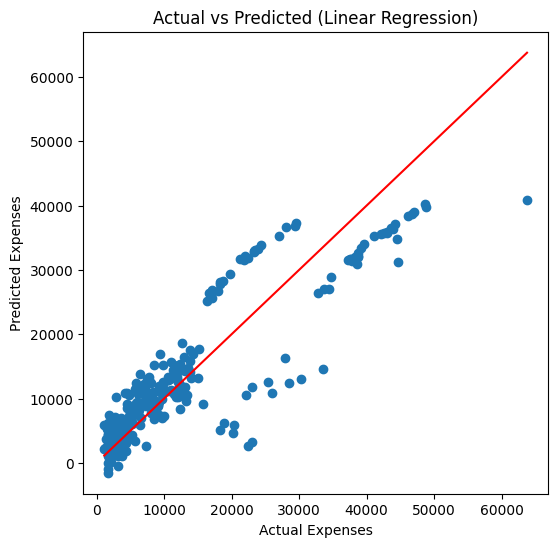

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_linear)
plt.xlabel("Actual Expenses")
plt.ylabel("Predicted Expenses")
plt.title("Actual vs Predicted (Linear Regression)")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

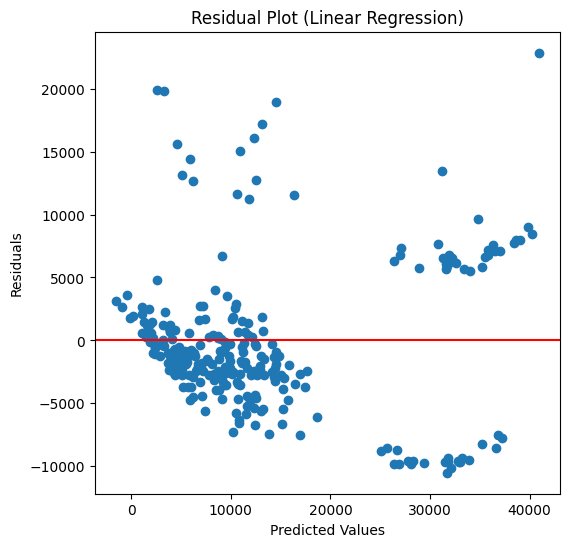

In [ ]:
residuals = y_test - y_pred_linear

plt.figure(figsize=(6,6))
plt.scatter(y_pred_linear, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.show()

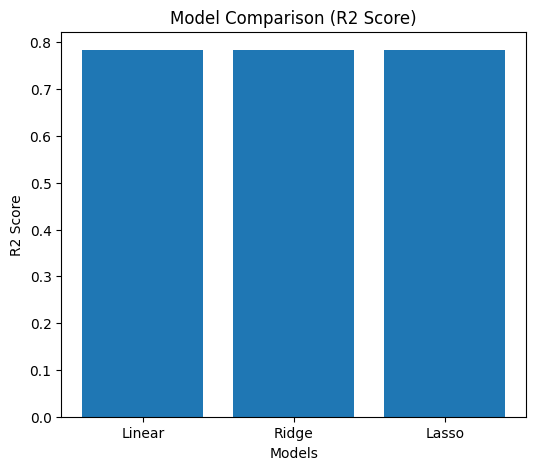

In [ ]:
models = ['Linear', 'Ridge', 'Lasso']
r2_scores = [r2_linear, r2_ridge, r2_lasso]

plt.figure(figsize=(6,5))
plt.bar(models, r2_scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Score)")
plt.show()